![IITIS](pictures/logoIITISduze.png)

# Wyżarzanie równoległe

In [30]:
# Implementation of the algorithm
import random
import numpy as np
from typing import Optional


clip = np.vectorize(lambda x: max(-1.0, min(1.0,x)))
scaling_func = np.vectorize(lambda x: 2*x-1)  # przesunięcie wartości z (0, 1) do (-1, 1)


def calculate_gradient(J: np.ndarray, h: np.ndarray, x: np.ndarray, state: np.ndarray, lambda_t: float) -> np.ndarray:
    return J @ state + h + lambda_t * x


def calculate_energy_ising(J: np.ndarray, h: np.ndarray, state: np.ndarray):
    return state @ J @ state.T + state @ h 


def calculate_energy_init(lambda_t: float, x: np.ndarray):
    return lambda_t * x @ x.T


def calculate_energy_system(lambda_t: float, x: np.ndarray, J: np.ndarray, h: np.ndarray, state: np.ndarray):
    return calculate_energy_init(lambda_t, x) + calculate_energy_ising(J, h, state)


def parrarel_annealing(J, h, step_size: float, lambda_t_max: float, num_steps: int, 
                       schedule: Optional[np.ndarray] = None, schedule_endpoint: Optional[float] = 0):
    n = len(h)
    x = np.zeros(n)  # stan podstawowy dla H_innit = sum(x**2)
    momentum = np.zeros(n)
    state = scaling_func(np.random.randint(2, size=(n,)))  # losowy stan początkowy

    if schedule is None:
        schedule = np.linspace(lambda_t_max, schedule_endpoint, num=num_steps)

    for k in range(num_steps):
        lambda_t = schedule[k]
        gradient = calculate_gradient(J, h, x, state, lambda_t)
        momentum = (1 - step_size) * momentum - step_size * gradient
        momentum = np.clip(momentum, -1, 1)
        x += momentum
        x = np.clip(x, -1, 1)
        state = np.sign(x)

    return state, calculate_energy_ising(J, h, state)



    


In [141]:
n = 20

scaling_func = np.vectorize(lambda x: 2*x-1)  # przesunięcie wartości z (0, 1) do (-1, 1)
J = np.triu(scaling_func(np.random.rand(n, n)))  # losowa gęsta macierz górnotrójkątna
h = scaling_func(np.random.rand(n))  # losowy wektor




In [124]:
from dimod import BinaryQuadraticModel
from dwave.samplers import SimulatedAnnealingSampler

bqm_instance = BinaryQuadraticModel(h, J, vartype="SPIN")
sampler= SimulatedAnnealingSampler()
sampleset = sampler.sample(bqm_instance, num_reads=1)
print(sampleset)
print(parrarel_annealing(J, h, 10, 0.005, 10000))

   0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19    energy num_oc.
0 +1 -1 +1 +1 -1 +1 -1 +1 +1 +1 -1 +1 -1 +1 -1 +1 -1 -1 -1 +1 -43.41361       1
['SPIN', 1 rows, 1 samples, 20 variables]
(array([-1.,  1., -1.,  1., -1., -1.,  1., -1., -1., -1., -1., -1.,  1.,
       -1.,  1., -1., -1., -1.,  1.,  1.]), np.float64(-31.45542953394546))


100%|██████████| 32/32 [00:06<00:00,  4.68it/s]

-270.0


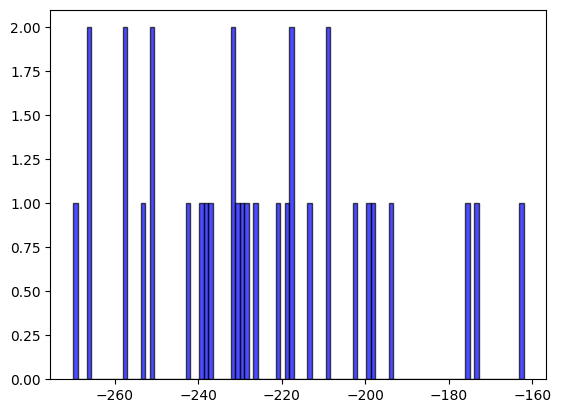

   0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 ... 215 energy num_oc.
0 +1 +1 +1 +1 -1 -1 -1 +1 +1 +1 +1 +1 -1 -1 -1 -1 +1 +1 ...  +1 -469.0       1
['SPIN', 1 rows, 1 samples, 216 variables]


In [33]:
# Działamy na większej instancji
# 216 spinów i geometryczna struktura QPU

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import inf
from tqdm import tqdm

instance_path = os.path.join("instancje", "P4", "P4_CBFM-P.txt")
# W pliku jest poza samą instancję jeszcze najlepsza znaleziona energia E = -469


def read_instance(path: os.PathLike):
    df = pd.read_csv(path, sep=" ", header=None, comment="#", names=["i", "j", "value"])

    n = max(df[["i", "j"]].max())
    h = np.zeros(n)
    J = np.zeros((n, n))
    
    for row in df.itertuples():
        if row.i == row.j:
            h[row.i - 1] = row.value
        elif row.i > row.j:
            J[row.j - 1, row.i - 1] = row.value  # by zachować górnotrójkątność
        else:
            J[row.i - 1, row.j - 1] = row.value
            
    return h, J

    
h, J = read_instance(instance_path)
num_trajectories = 2 ** 5

best_energy = inf
best_state = None
energies = []

for _ in tqdm(range(num_trajectories)):
    state, energy = parrarel_annealing(J, h, 10, 0.01, 10000)
    energies.append(energy)

print(min(energies))

plt.hist(energies, bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.show()


from dimod import BinaryQuadraticModel
from dwave.samplers import SimulatedAnnealingSampler

bqm_instance = BinaryQuadraticModel(h, J, vartype="SPIN")
sampler= SimulatedAnnealingSampler()
sampleset = sampler.sample(bqm_instance, num_reads=1)
print(sampleset)

In [226]:
# Wyżarzanie równoległe wiele trajektorii

def parrarel_annealing_multiple_trajectores(J, h, step_size: float, lambda_t_max: float, num_steps: int, num_trials: int,
                       schedule: Optional[np.ndarray] = None, schedule_endpoint: Optional[float] = 0):
    n = len(h)
    x = np.zeros((num_trials, n))  # stan podstawowy dla H_innit = sum(x**2)
    momentum = np.zeros((num_trials, n))
    state = scaling_func(np.random.randint(2, size=(num_trials, n)))  # losowy stan początkowy

    if schedule is None:
        schedule = np.linspace(lambda_t_max, schedule_endpoint, num=num_steps)

    for k in range(num_steps):
        lambda_t = schedule[k]
        gradient = state @ J  + np.stack([h] * num_trials, axis=0) + lambda_t * x
        momentum = 0.99 * momentum - step_size * gradient
        momentum = np.clip(momentum, -1, 1)
        x += momentum
        x = np.clip(momentum, -1, 1)
        state = np.sign(x)

    return state



In [228]:
parrarel_annealing_multiple_trajectores(J, h, 10, 0.01, 100000, 5)


array([[ 0.,  1.,  1., ..., -1.,  1.,  1.],
       [ 0.,  1.,  1., ..., -1.,  1.,  1.],
       [ 0., -1.,  1., ..., -1.,  1.,  1.],
       [ 0., -1.,  1., ..., -1.,  1., -1.],
       [ 0.,  1.,  1., ..., -1.,  1., -1.]], shape=(5, 216))

: 

-371.0


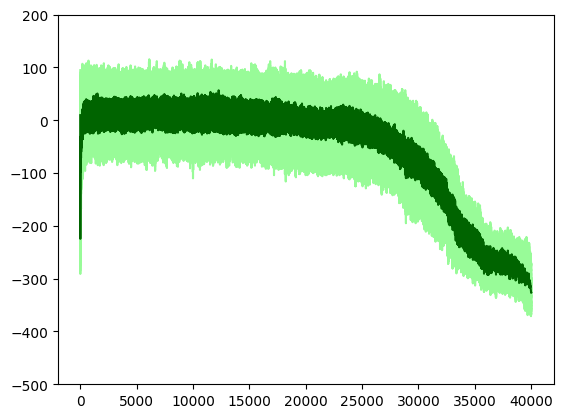

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# parameter chosing
numTrials = 100
numIterations = 40000   # predefined number of iterations
numSpins = 216  # number of spins (Problem size N)
adpRate = 0.02    # learning rate/step size
lamda = np.linspace(10,0,numIterations)     # coefficient of initial Hamiltonian

# initilization
spinVector = np.random.randint(2,size=(numSpins,numTrials))*2-1.0   # randomly initialize spin configurations
xVector = np.zeros((numSpins,numTrials))    # zero initialize classical "superposition"
momentum = np.zeros((numSpins,numTrials))    # zero initialize momentum
isingHamil = np.zeros(numTrials)    # Ising Hamiltonian
isingHamilHistory = np.zeros((numIterations,numTrials))  # Ising Hamiltonian History

coulpingMatrix = J
externalFields = np.stack([h] * numTrials, axis=1)  

# run
for ii in np.arange(numIterations):
    delHising = np.dot(coulpingMatrix, spinVector) + externalFields    # can be implemented experimentally by memristor crossbar array
    delHinit = xVector
    delHsystem = delHising + lamda[ii]*delHinit
    momentum = (1-2*adpRate)*momentum - adpRate*delHsystem    # update momentum
    momentum = np.clip(momentum,-1,1)   # clip momentum
    xVector += momentum     # update classical "superposition"
    xVector = np.clip(xVector,-1,1 )    # clip classical "superposition"
    spinVector = np.sign(xVector)
    for tt in np.arange(numTrials):  
        isingHamil[tt] = np.dot(spinVector[:,tt].T, (coulpingMatrix @ spinVector[:,tt])) + spinVector[:,tt].T @ externalFields[:, tt]   # calculate Ising Hamiltonian
    isingHamilHistory[ii] = isingHamil      # energy tracking

for tt in np.arange(numTrials): 
    plt.plot(isingHamilHistory[:,tt], color = 'palegreen')
plt.plot(np.mean(isingHamilHistory,axis=1), color='darkgreen')
plt.ylim(-500,200)

print(np.min(isingHamilHistory))
